# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"
pokemon_df = pd.read_csv(fp)
pokemon_df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

Text(0.5, 1.05, 'Relationship between Attack and Defense in All Pokemon')

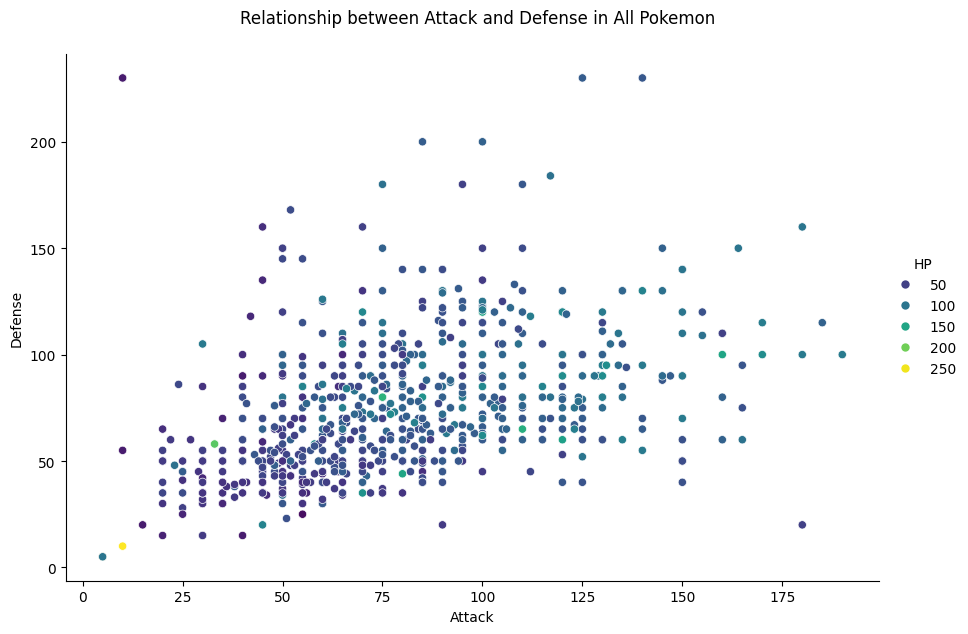

In [28]:
# Your code here . . .
g = sns.relplot(
    data=pokemon_df,
    x="Attack",
    y="Defense",
    hue="HP",
    palette="viridis",
    height=6,
    aspect=1.5
)
g.fig.suptitle("Relationship between Attack and Defense in All Pokemon", y=1.05)

### From the plot, I observed....
Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values. But the dots aren't in a perfect straight line. This means while there is a general trend, there is a lot of variance.

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

Text(0.5, 1.05, 'Relationship between Attack and Total in All Pokemon')

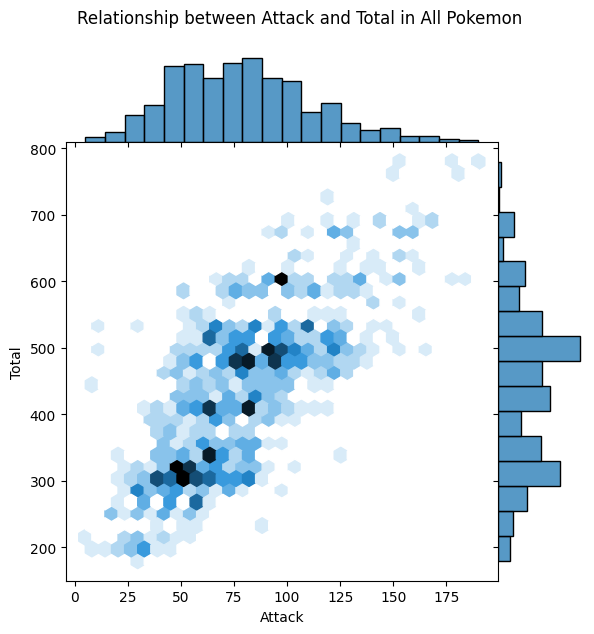

In [29]:
# Your code here . . .
g = sns.jointplot(
    data=pokemon_df,
    x="Attack",
    y="Total",
    kind="hex",
    gridsize=30,
    height=6,
    space=0
)
g.fig.suptitle("Relationship between Attack and Total in All Pokemon", y=1.05)

### From the plot, I observed....
Results: Since the cloud of hexagons generally moves from the bottom-left toward the top-right, we can see a positive correlation between Attack and Total. Additionally, there are dark clusters of hexagons located around 50 Attack / 300 Total and 100 Attack / 500 Total, meaning these are the most common stat combinations. The top bar chart shows that most Pokemon have an Attack stat ranging from 50 to 100, and the right bar chart shows a significant peak of Pokemon with a Total stat of around 500.

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

Text(0.5, 1.05, 'Count of Type 1 Pokemon')

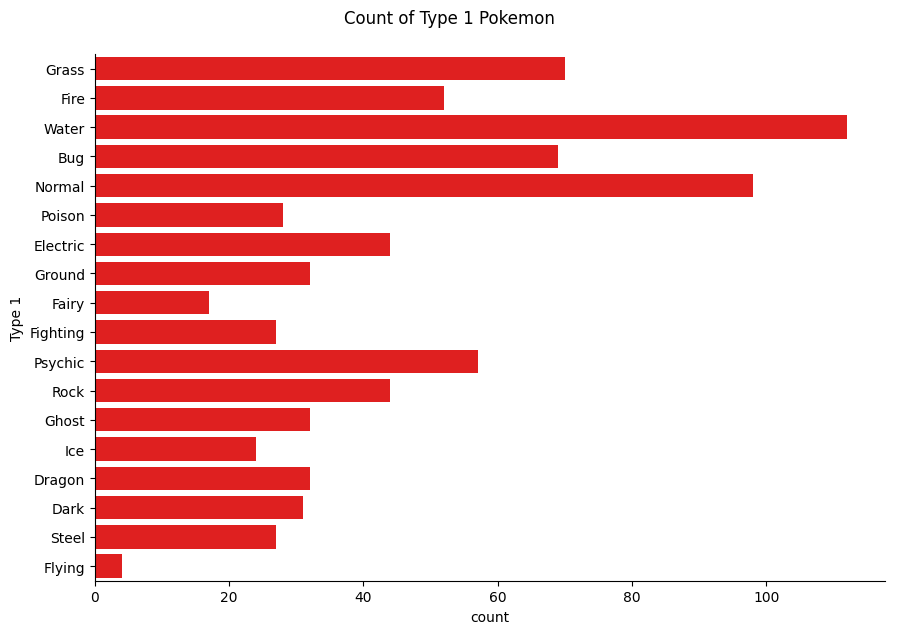

In [39]:
# Your code here . . .
g = sns.catplot(
    data=pokemon_df,
    y="Type 1",
    kind="count",
    color="red",
    height=6,
    aspect=1.5
)
g.fig.suptitle("Count of Type 1 Pokemon", y=1.05
)

Text(0.5, 1.05, 'Count of Type 2 Pokemon')

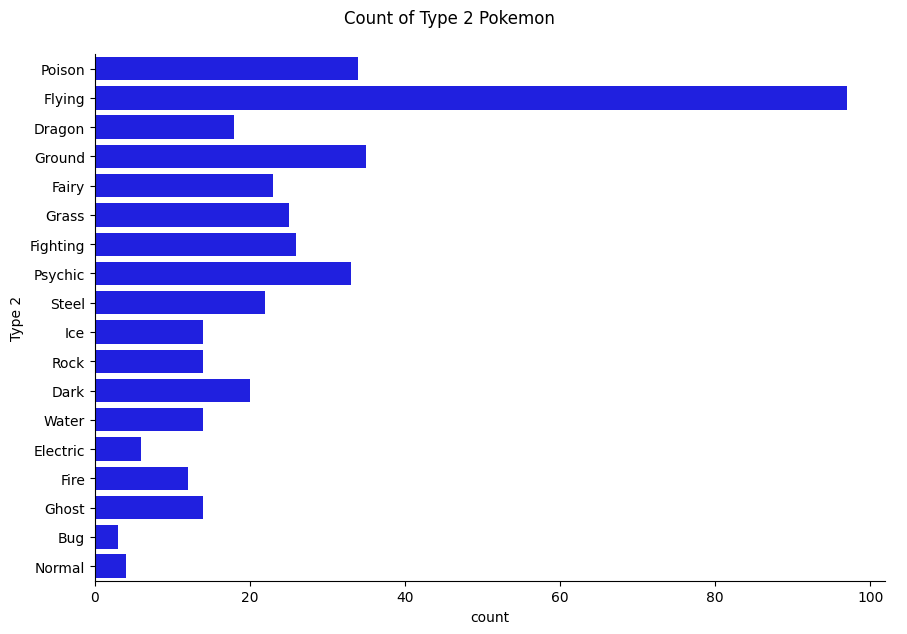

In [40]:
g = sns.catplot(
    data=pokemon_df,
    y="Type 2",
    kind="count",
    color="blue",
    height=6,
    aspect=1.5
)
g.fig.suptitle("Count of Type 2 Pokemon", y=1.05
)

### From the plot, I observed....
Results: For type 1, the most common Pokemon is water and most rare is flying. For type 2, the most common one is flying and the most rare is bug.

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

Your questions . . .
1) What is the most common primary type (Type 1) among Legendary Pokemon?
2) Which Generation introduced the Pokemon with the highest average 'Total' stats?
3) What is the relationship between Speed and Attack?

Text(0.5, 1.05, 'Count of Type 1 Legendary Pokemon')

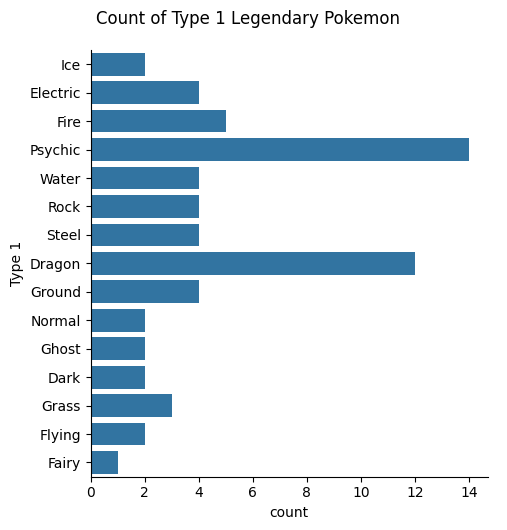

In [41]:
# Your code here . . .
# 1. What is the most common primary type (Type 1) among Legendary Pokemon?
# Filter the df with only legendary pokemon:
legendary_df = pokemon_df[pokemon_df['Legendary'] == True]
g = sns.catplot(
    data=legendary_df,
    y="Type 1",
    kind="count"
    )
g.fig.suptitle("Count of Type 1 Legendary Pokemon", y=1.05
)

### What is the most common primary type (Type 1) among Legendary Pokemon?
Result: According to the plot, Psychic is the most common type of Type 1 among Legendary Pokemon. Dragon is the second most common type.


Text(0.5, 1.05, 'Average Total Stats by Generation')

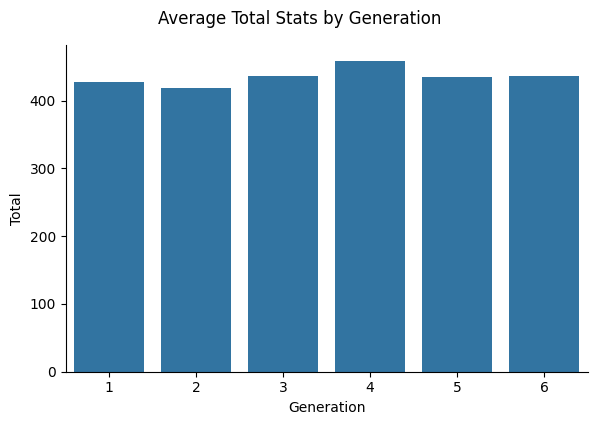

In [45]:
# 2. Which Generation introduced the Pokemon with the highest average 'Total' stats?
g = sns.catplot(
    data=pokemon_df,
    x="Generation",
    y="Total", # automatically calculate the mean of y
    kind="bar",
    height=4,
    aspect=1.5,
    errorbar=None
)
g.fig.suptitle("Average Total Stats by Generation", y=1.05
)

### Which Generation introduced the Pokemon with the highest average 'Total' stats?
Result: The bar chart shows that the average 'Total' stats are consistent across all six Generations. However, Generation 4 has a slightly higher average 'Total' than the others.

Text(0.5, 1.05, 'Relationship between Speed and Attack in All Pokemon')

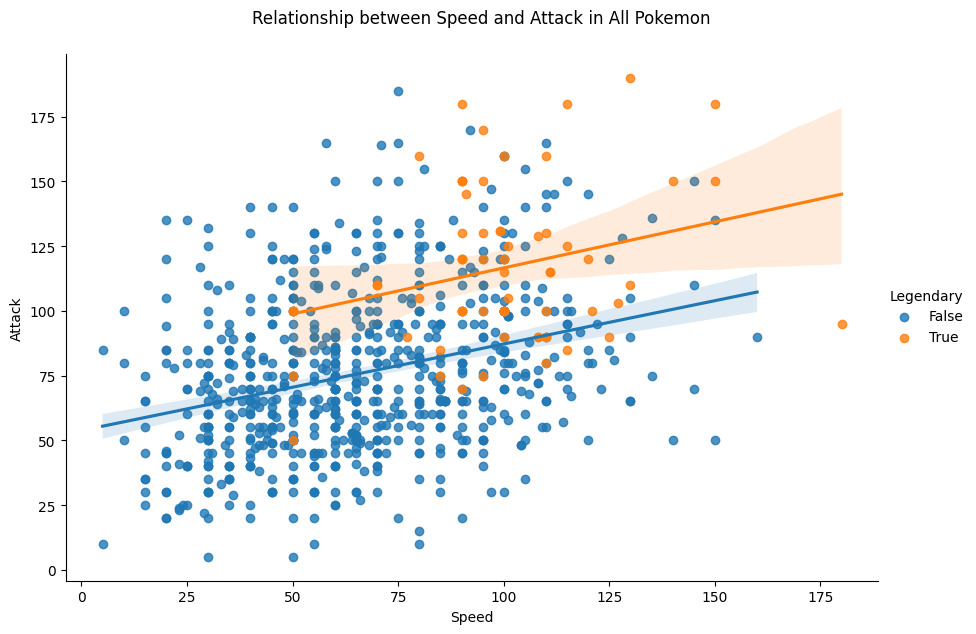

In [51]:
# 3. What is the relationship between Speed and Attack?
# use lmplot to make a more clear observation
g = sns.lmplot(
    data=pokemon_df,
    x = "Speed",
    y = "Attack",
    hue = "Legendary",
    height = 6,
    aspect = 1.5
)
g.fig.suptitle("Relationship between Speed and Attack in All Pokemon", y = 1.05)

### What is the relationship between Speed and Attack?
Result: For both Legendary and non-Legendary Pokemon, there is a general positive correlation between Speed and Attack. The orange line for Legendary Pokemon has higher position on the Y-axis than the line for non-Legendary Pokemon, which means on average Legendary Pokemon have a higher base Attack regardless of their Speed.